# Course 3 - Applied Machine Learning Using Python
## Assignment 3: Evaluation Metrics and Model Selection for Fraud Detection

### Overview
This assignment focuses on model evaluation beyond simple accuracy. Using a highly imbalanced credit card fraud dataset, you will compare classifiers using precision, recall, confusion matrices, precision-recall curves, ROC curves, and grid search. Imbalanced datasets like fraud detection require careful metric selection because a naive "predict all non-fraud" classifier can achieve 98%+ accuracy while being completely useless.

### Learning Objectives
- Understand why accuracy alone is a poor metric for imbalanced datasets
- Compute and interpret precision, recall, and confusion matrices
- Plot and read precision-recall curves and ROC curves
- Apply threshold adjustment to control the precision-recall tradeoff
- Tune logistic regression using GridSearchCV with recall as the scoring metric

### Dataset
- **File:** `assets/fraud_data.csv`
- **Target:** `Class` column (0 = legitimate, 1 = fraud)
- **Imbalance:** ~1.6% fraud, ~98.4% legitimate transactions
- Train/test split with `random_state=0`

### Assignment Structure
| Question | Task |
|----------|------|
| Q1 | Compute the percentage of fraud instances in the dataset |
| Q2 | Train a DummyClassifier (majority class); report accuracy and recall |
| Q3 | Train an SVC; report accuracy, recall, and precision |
| Q4 | SVC with C=1e9, gamma=1e-7; confusion matrix at threshold=-220 |
| Q5 | Logistic Regression; find recall at precision=0.75 and TPR at FPR=0.16 |
| Q6 | GridSearchCV over L1/L2 penalty and C=[0.01,0.1,1,10]; return 4x2 score array |

---
_You are currently looking at **version 0.1** of this notebook._

In [1]:
import numpy as np
import pandas as pd

### Question 1
Import the data from `assets/fraud_data.csv`. What percentage of the observations in the dataset are instances of fraud?

*This function should return a float between 0 and 1.* 

In [2]:
fraud_data = pd.read_csv('assets/fraud_data.csv')
print(fraud_data['Class'].head(2))
print(np.bincount(fraud_data['Class']))

percentage_fraud = np.bincount(fraud_data['Class'])[1]/np.sum((np.bincount(fraud_data['Class'])))
percentage_fraud


0    0
1    0
Name: Class, dtype: int64
[21337   356]


0.016410823768035772

In [3]:
def answer_one():
    # YOUR CODE HERE
    fraud_data = pd.read_csv('assets/fraud_data.csv')
    fraud_data.head(2)
    np.bincount(fraud_data['Class'])

    percentage_fraud = np.bincount(fraud_data['Class'])[1]/np.sum((np.bincount(fraud_data['Class'])))
    percentage_fraud
    return percentage_fraud
    raise NotImplementedError()


In [4]:
# Use X_train, X_test, y_train, y_test for all of the following questions
from sklearn.model_selection import train_test_split

df = pd.read_csv('assets/fraud_data.csv')

X = df.iloc[:,:-1]
y = df.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

### Question 2

Using `X_train`, `X_test`, `y_train`, and `y_test` (as defined above), train a dummy classifier that classifies everything as the majority class of the training data. What is the accuracy of this classifier? What is the recall?

*This function should a return a tuple with two floats, i.e. `(accuracy score, recall score)`.*

In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import recall_score,accuracy_score, precision_score

    # YOUR CODE HERE
dummy_majority = DummyClassifier(strategy ='most_frequent' ).fit(X_train, y_train)
dummy_majority.score(X_test,y_test)
y_pred = dummy_majority.predict(X_test)
print(' Accuracy score is : {:.3f}'.format(accuracy_score(y_test,y_pred)))
print(' Recall score is : {:.3f}'.format(recall_score(y_test,y_pred)))


 Accuracy score is : 0.985
 Recall score is : 0.000


In [6]:
def answer_two():
    from sklearn.dummy import DummyClassifier
    from sklearn.metrics import recall_score

    # YOUR CODE HERE
    dummy_majority = DummyClassifier(strategy ='most_frequent' ).fit(X_train, y_train)
    from sklearn.dummy import DummyClassifier
    from sklearn.metrics import recall_score,accuracy_score, precision_score

    # YOUR CODE HERE
    dummy_majority = DummyClassifier(strategy ='most_frequent' ).fit(X_train, y_train)
    dummy_majority.score(X_test,y_test)
    y_pred = dummy_majority.predict(X_test)
    
    print(' Accuracy score is : {:.3f}'.format(accuracy_score(y_test,y_pred)))
    print(' Recall score is : {:.3f}'.format(recall_score(y_test,y_pred)))
    return ( accuracy_score(y_test,y_pred), 
                   precision_score(y_test,y_pred))
    raise NotImplementedError()

### Question 3

Using X_train, X_test, y_train, y_test (as defined above), train a SVC classifer using the default parameters. What is the accuracy, recall, and precision of this classifier?

*This function should a return a tuple with three floats, i.e. `(accuracy score, recall score, precision score)`.*

In [7]:
    from sklearn.metrics import recall_score, precision_score, accuracy_score
    from sklearn.svm import SVC
    
    # YOUR CODE HERE
    SVC_classifier = SVC(random_state =0).fit(X_train, y_train)
    y_pred = SVC_classifier.predict(X_test)
    print("Accuracy Score: \n", accuracy_score(y_test, y_pred))
    print("Recall Score: \n ", recall_score(y_test, y_pred))
    print("Precision Score: \n ", precision_score(y_test, y_pred))
    

Accuracy Score: 
 0.9900442477876106
Recall Score: 
  0.35
Precision Score: 
  0.9333333333333333


In [8]:
def answer_three():
    from sklearn.metrics import recall_score, precision_score, precision_recall_curve
    from sklearn.svm import SVC
    
    # YOUR CODE HERE
    SVC_classifier = SVC(random_state =0).fit(X_train, y_train)
    y_pred = SVC_classifier.predict(X_test)
    print("Accuracy Score: \n", accuracy_score(y_test, y_pred))
    print("Recall Score: \n ", recall_score(y_test, y_pred))
    print("Precision Score: \n ", precision_score(y_test, y_pred))
    return (accuracy_score(y_test, y_pred), 
                  recall_score(y_test, y_pred), 
                 precision_score(y_test, y_pred)
           )
    raise NotImplementedError()

### Question 4

Using the SVC classifier with parameters `{'C': 1e9, 'gamma': 1e-07}`, what is the confusion matrix when using a threshold of -220 on the decision function. Use X_test and y_test.

*This function should return a confusion matrix, a 2x2 numpy array with 4 integers.*

In [9]:
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC

SVC_Classifier1 = SVC(C=1e9, gamma=1e-07, random_state=0, probability=True)
SVC_Classifier1.fit(X_train, y_train)
y_scores_svc = SVC_Classifier1.decision_function(X_test)

# Predict first, then threshold
y_predicted_svc = SVC_Classifier1.predict(X_test)
y_scores_threshold = np.where(y_scores_svc > -220, 1, 0)

print("Threshold confusion matrix:")
print(confusion_matrix(y_test, y_scores_threshold))
print("Standard prediction confusion matrix:")
print(confusion_matrix(y_test, y_predicted_svc))

Threshold confusion matrix:
[[5320   24]
 [  14   66]]
Standard prediction confusion matrix:
[[5340    4]
 [  16   64]]


In [10]:
def answer_four():
    from sklearn.metrics import confusion_matrix
    from sklearn.svm import SVC
    
    # YOUR CODE HERE
    from sklearn.metrics import confusion_matrix, precision_recall_curve
    
    from sklearn.svm import SVC
    
    
    SVC_Classifier1 = SVC(C=1e9, gamma=1e-07, random_state =0, probability = True)
    SVC_Classifier1 .fit(X_train, y_train)
    y_scores_svc= SVC_Classifier1.decision_function(X_test)
    #y_pred = SVC_classifier.predict(X_test)
    y_scores_list = list(zip( y_test[0:20], y_scores_svc[0:20]))
    #print(y_scores_svc)
    
    y_predicted_svc = SVC_Classifier1.predict(X_test)
    #print(y_scores_svc> -220)
    y_scores_threshold = np.where(y_scores_svc> -220, 1,0)
    
    print(y_scores_threshold)
    #print(list(zip(y_test,y_scores_svc, y_scores_threshold)))
    
    a =confusion_matrix(y_test, y_scores_threshold)
    b =confusion_matrix(y_test, y_predicted_svc)
    
    print(a)
    print(b)
    return a
    raise NotImplementedError()

### Question 5

Train a logisitic regression classifier with default parameters using X_train and y_train.

For the logisitic regression classifier, create a precision recall curve and a roc curve using y_test and the probability estimates for X_test (probability it is fraud).

Looking at the precision recall curve, what is the recall when the precision is `0.75`?

Looking at the roc curve, what is the true positive rate when the false positive rate is `0.16`?

*This function should return a tuple with two floats, i.e. `(recall, true positive rate)`.*

In [11]:
def answer_five():
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import precision_recall_curve, roc_curve,auc , classification_report
    import matplotlib.pyplot as plt
    # YOUR CODE HERE
    logReg = LogisticRegression(random_state =0, solver ='liblinear').fit(X_train, y_train)
    #print(np.array(X_test))
    y_scores_lr = logReg.decision_function(np.array(X_test))
    y_predict_lr = logReg.predict(X_test)
    y_proba_logReg = logReg.predict_proba(np.array(X_test))

    #print(X_test.describe)
    #print(type(y_proba_logReg))
    prob_of_fraud = map(lambda x: x[1] , y_proba_logReg )
    prob_of_fraud_array = np.array(list(prob_of_fraud))
    prob_of_fraud_array2d = prob_of_fraud_array.reshape(-1,1)
    #print(prob_of_fraud_array.reshape(-1,1))

    #print(list(zip(y_test, y_proba_logReg)))
    #y_scores_predicted_proba

    precision, recall, thresholds = precision_recall_curve(y_test,prob_of_fraud_array2d)

    fig_1 = plt.figure(figsize = (12,8))
    axes_1 = fig_1.add_axes([0.1, 0.1, 0.9, 0.9])
    axes_1.plot(precision, recall,  'b-',label='Precision-Recall Curve')
    axes_1.set_xlabel('Precision', fontsize=16)
    axes_1.set_ylabel('Recall', fontsize=16)

    print(precision)

    closest_desired_precision = np.argmin(abs(precision-0.75))
    #closest_zero_p = precision[closest_desired_precision]
    closest_desired_r = recall[closest_desired_precision]
    axes_1.plot(0.75, closest_desired_r, 'o', markersize = 12, fillstyle = 'none', c='r', mew=3)

    #fig_1.plot(precision, recall,  'bx',label='Precision-Recall Curve')
    fpr_lr, tpr_lr, _ = roc_curve(y_test, prob_of_fraud_array2d)
    closest_desired_fpr = np.argmin(abs(fpr_lr-0.16))
    closest_desired_tpr = tpr_lr[closest_desired_fpr]
    recallAt_fpr_16 = np.interp(0.16, precision, recall)
    
    print("Desired Metrics" , closest_desired_r, closest_desired_tpr, recallAt_fpr_16)
    roc_auc_lr = auc(fpr_lr, tpr_lr)

    fig_2 = plt.figure(figsize = (12,8))
    axes_2 = fig_2.add_axes([0.1, 0.1, 0.9, 0.9])
    axes_2.plot(fpr_lr, tpr_lr,  'b-', label='LogRegr ROC curve (area = {:0.2f})'.format(roc_auc_lr))
    axes_2.set_xlabel('False Positive Rate', fontsize=16)
    axes_2.set_ylabel('True Positive Rate', fontsize=16)
    axes_2.legend()
    return (closest_desired_r, closest_desired_tpr)
    
    raise NotImplementedError()



[0.01474926 0.01475198 0.0147547  ... 1.         1.         1.        ]
Desired Metrics 0.825 0.9375 0.8875


C:\Users\singl\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\singl\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


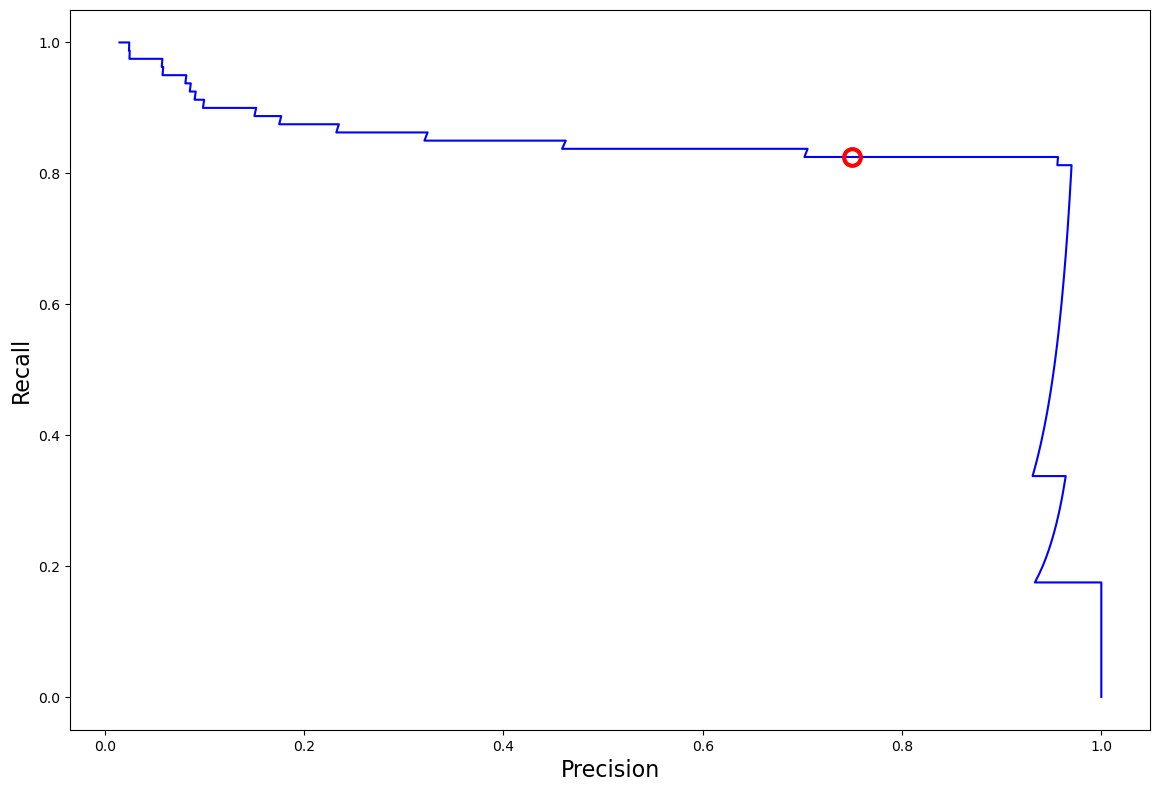

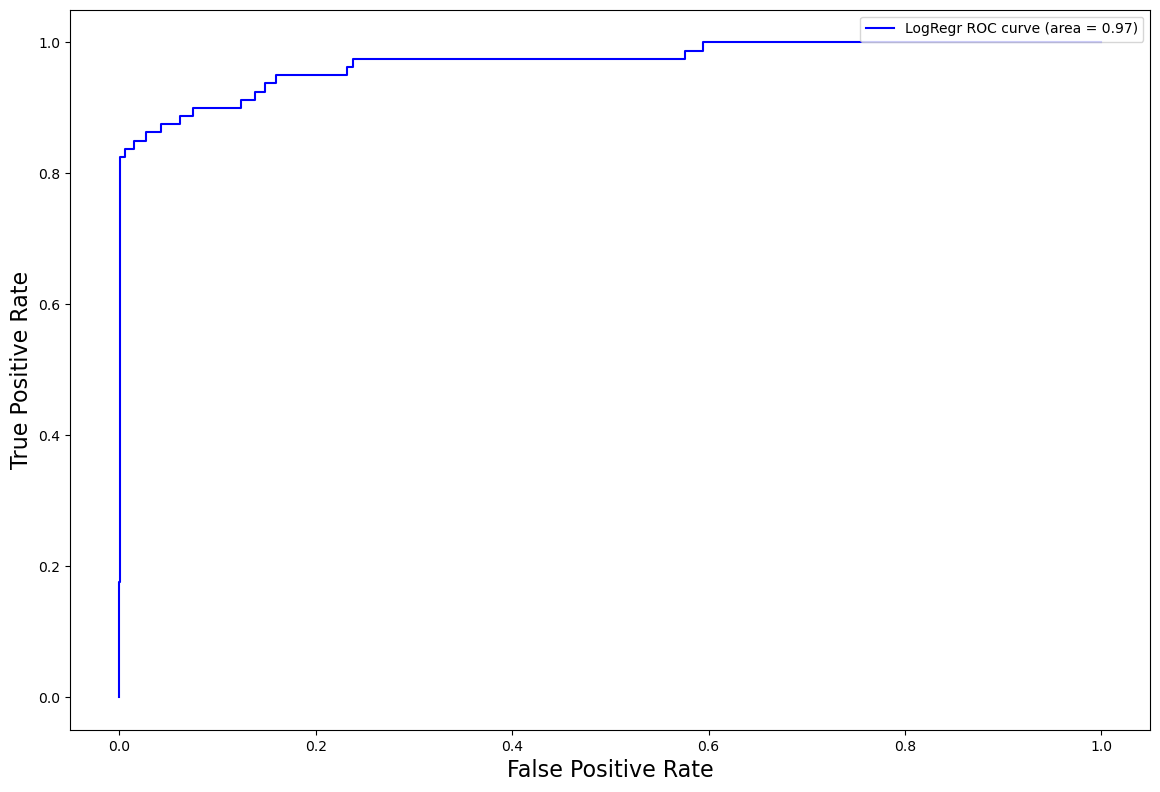

In [12]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, roc_curve,auc , classification_report
import matplotlib.pyplot as plt

logReg = LogisticRegression(random_state =0, solver = 'liblinear').fit(X_train, y_train)
#print(np.array(X_test))
y_scores_lr = logReg.decision_function(np.array(X_test))
y_predict_lr = logReg.predict(X_test)
y_proba_logReg = logReg.predict_proba(np.array(X_test))

#print(X_test.describe)
#print(type(y_proba_logReg))
prob_of_fraud = map(lambda x: x[1] , y_proba_logReg )
prob_of_fraud_array = np.array(list(prob_of_fraud))
prob_of_fraud_array2d = prob_of_fraud_array.reshape(-1,1)
#print(prob_of_fraud_array.reshape(-1,1))

#print(list(zip(y_test, y_proba_logReg)))
#y_scores_predicted_proba

precision, recall, thresholds = precision_recall_curve(y_test,prob_of_fraud_array2d)

fig_1 = plt.figure(figsize = (12,8))
axes_1 = fig_1.add_axes([0.1, 0.1, 0.9, 0.9])
axes_1.plot(precision, recall,  'b-',label='Precision-Recall Curve')
axes_1.set_xlabel('Precision', fontsize=16)
axes_1.set_ylabel('Recall', fontsize=16)

print(precision)

closest_desired_precision = np.argmin(abs(precision-0.75))
#closest_zero_p = precision[closest_desired_precision]
closest_desired_r = recall[closest_desired_precision]
axes_1.plot(0.75, closest_desired_r, 'o', markersize = 12, fillstyle = 'none', c='r', mew=3)

#fig_1.plot(precision, recall,  'bx',label='Precision-Recall Curve')
fpr_lr, tpr_lr, _ = roc_curve(y_test, prob_of_fraud_array2d)
closest_desired_fpr = np.argmin(abs(fpr_lr-0.16))
closest_desired_tpr = tpr_lr[closest_desired_fpr]
recallAt_fpr_16 = np.interp(0.16, precision, recall)
print("Desired Metrics" , closest_desired_r, closest_desired_tpr,recallAt_fpr_16)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fig_2 = plt.figure(figsize = (12,8))
axes_2 = fig_2.add_axes([0.1, 0.1, 0.9, 0.9])
axes_2.plot(fpr_lr, tpr_lr,  'b-', label='LogRegr ROC curve (area = {:0.2f})'.format(roc_auc_lr))
axes_2.set_xlabel('False Positive Rate', fontsize=16)
axes_2.set_ylabel('True Positive Rate', fontsize=16)
axes_2.legend()

# YOUR CODE HERE
#raise NotImplementedError()

### Question 6

Perform a grid search over the parameters listed below for a Logisitic Regression classifier, using recall for scoring and the default 3-fold cross validation. (Suggest to use `solver='liblinear'`, more explanation [here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html))

`'penalty': ['l1', 'l2']`

`'C':[0.01, 0.1, 1, 10]`

From `.cv_results_`, create an array of the mean test scores of each parameter combination. i.e.

|      	| `l1` 	| `l2` 	|
|:----:	|----	|----	|
| **`0.01`** 	|    ?	|   ? 	|
| **`0.1`**  	|    ?	|   ? 	|
| **`1`**    	|    ?	|   ? 	|
| **`10`**   	|    ?	|   ? 	|

<br>

*This function should return a 4 by 2 numpy array with 8 floats.* 

*Note: do not return a DataFrame, just the values denoted by `?` in a numpy array.*

In [13]:
def answer_six():    
    from sklearn.model_selection import GridSearchCV
    from sklearn.linear_model import LogisticRegression

    # Grid search over L1/L2 penalty and C values, optimizing for recall
    # Higher recall = fewer missed fraud cases (at cost of more false positives)
    param_grid = {
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10]
    }
    lr = LogisticRegression(solver='liblinear')
    grid_clf = GridSearchCV(lr, param_grid=param_grid, scoring='recall', cv=3)
    grid_clf.fit(X_train, y_train)

    # Extract mean test scores and reshape to (4 C values x 2 penalties)
    scores = grid_clf.cv_results_['mean_test_score']
    return scores.reshape(4, 2)

answer_six()

array([[0.66666667, 0.76086957],
       [0.80072464, 0.80434783],
       [0.8115942 , 0.8115942 ],
       [0.80797101, 0.8115942 ]])

In [14]:
# Use the following function to help visualize results from the grid search
def GridSearch_Heatmap(scores):
    %matplotlib notebook
    import seaborn as sns
    import matplotlib.pyplot as plt
    plt.figure()
    sns.heatmap(scores.reshape(5,2), xticklabels=['l1','l2'], yticklabels=[0.01, 0.1, 1, 10])
    plt.yticks(rotation=0);

#GridSearch_Heatmap(answer_six())